In [1]:
# Импортируем библиотеки

import numpy as np
import pandas as pd
import seaborn as sns
sns.set_palette('husl')
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.decomposition import PCA

In [2]:
# Загружаем датасет из файла

dataset = pd.read_csv('/content/sample_data/dota2HeroPick.csv', index_col=0)

# Названия столбцов
cols = list(dataset.columns)
print(dataset.head())

                 Name Primary Attribute Attack Type  Attack Range  \
0             Abaddon               all       Melee           150   
1           Alchemist               str       Melee           150   
2  Ancient Apparition               int      Ranged           675   
3           Anti-Mage               agi       Melee           150   
4          Arc Warden               agi      Ranged           625   

                                               Roles  Total Pro wins  \
0                            Support, Carry, Durable               8   
1  Carry, Support, Durable, Disabler, Initiator, ...              23   
2                           Support, Disabler, Nuker              40   
3                               Carry, Escape, Nuker              40   
4                               Carry, Escape, Nuker               5   

   Times Picked  Times Banned  Win Rate  Niche Hero?  
0            24            61     33.33        False  
1            55            22     41.82   

In [3]:
vals = dataset["Primary Attribute"].unique()
vals

array(['all', 'str', 'int', 'agi'], dtype=object)

In [4]:
# Сохраняем только числовые столбцы. Категориальные кодируем в числовые. Целевую переменную (если она есть) - убираем
cols_for_clusters = ['Attack Range', 'Total Pro wins', 'Times Picked', 'Times Banned', 'Win Rate']

df = dataset[cols_for_clusters].copy()  # делаем копию, чтобы не было сюрпризов с исходным набором данных

In [5]:
X = df
y = dataset["Primary Attribute"].replace(vals, [0, 1, 2, 3])
yvals = dataset["Primary Attribute"]

/tmp/ipykernel_3787/516216298.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = dataset["Primary Attribute"].replace(vals, [0, 1, 2, 3])


In [6]:
from sklearn.preprocessing import StandardScaler

# Стандартизация числовых признаков
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA на стандартизированных данных
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(f"Объяснённая дисперсия: {pca.explained_variance_ratio_.sum():.2%}")

Объяснённая дисперсия: 74.10%


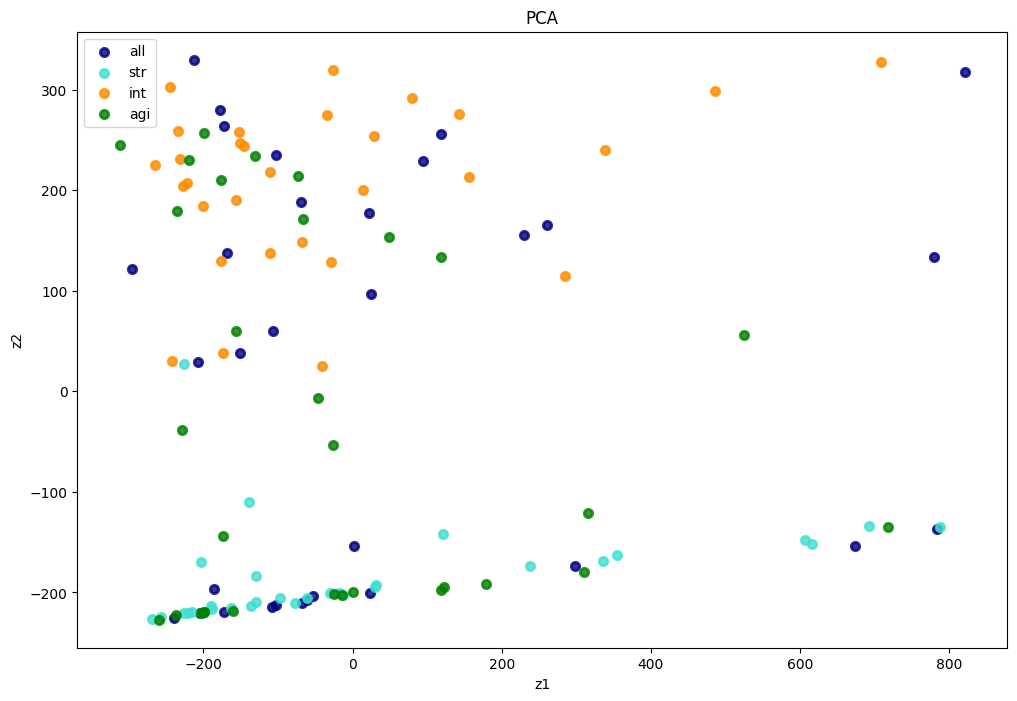

In [7]:
pca = PCA(n_components=2)
X_new = pca.fit(X).transform(X)

plt.figure(figsize=(12, 8))
colors = ["navy", "turquoise", "darkorange", "green"]
lw = 2

for color, i, target_name in zip(colors, [0, 1, 2, 3], vals):
    plt.scatter(
        X_new[y == i, 0], X_new[y == i, 1], color=color, alpha=0.8, lw=lw, label=vals[i]
    )

plt.legend(loc="best", shadow=False, scatterpoints=1)
plt.title("PCA")
plt.xlabel("z1")
plt.ylabel("z2")
plt.show()

In [8]:
pca.explained_variance_ratio_

array([0.60234315, 0.32078957])

In [9]:
from sklearn.decomposition import FastICA

fast_ica = FastICA(n_components=2)
X_new = fast_ica.fit_transform(X)

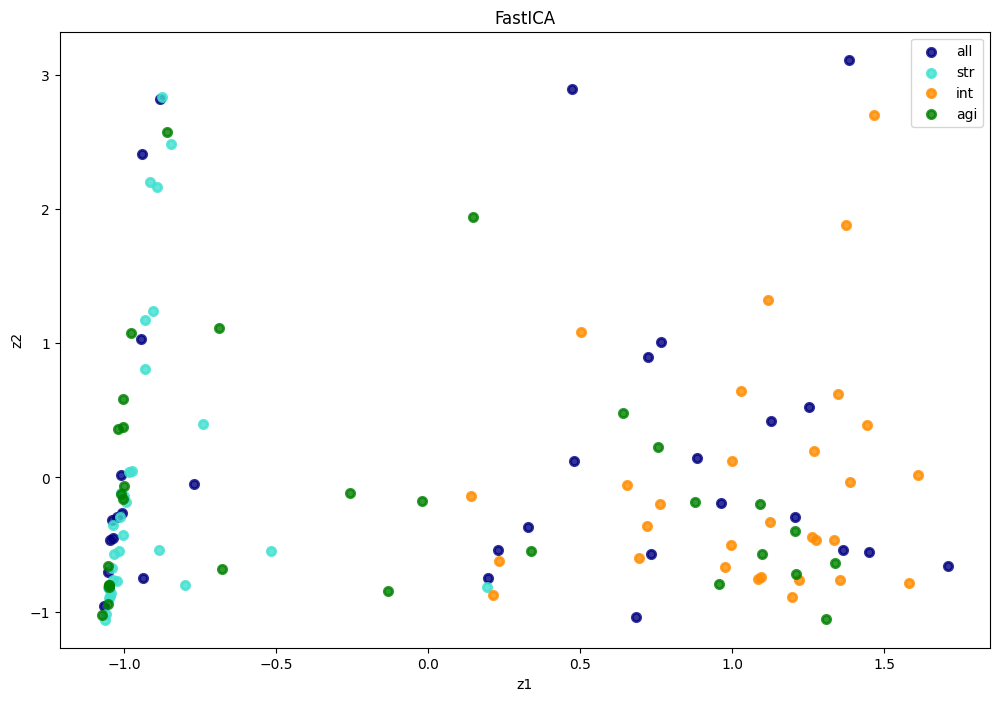

In [10]:
plt.figure(figsize=(12, 8))
colors = ["navy", "turquoise", "darkorange", "green"]
lw = 2

for color, i, target_name in zip(colors, [0, 1, 2, 3], vals):
    plt.scatter(
        X_new[y == i, 0], X_new[y == i, 1], color=color, alpha=0.8, lw=lw, label=vals[i]
    )

plt.legend(loc="best", shadow=False, scatterpoints=1)
plt.title("FastICA")
plt.xlabel("z1")
plt.ylabel("z2")
plt.show()

In [11]:
from sklearn.decomposition import KernelPCA

rbf_pca = KernelPCA(n_components=2, kernel='rbf', gamma=0.04)
X_new = rbf_pca.fit_transform(X)

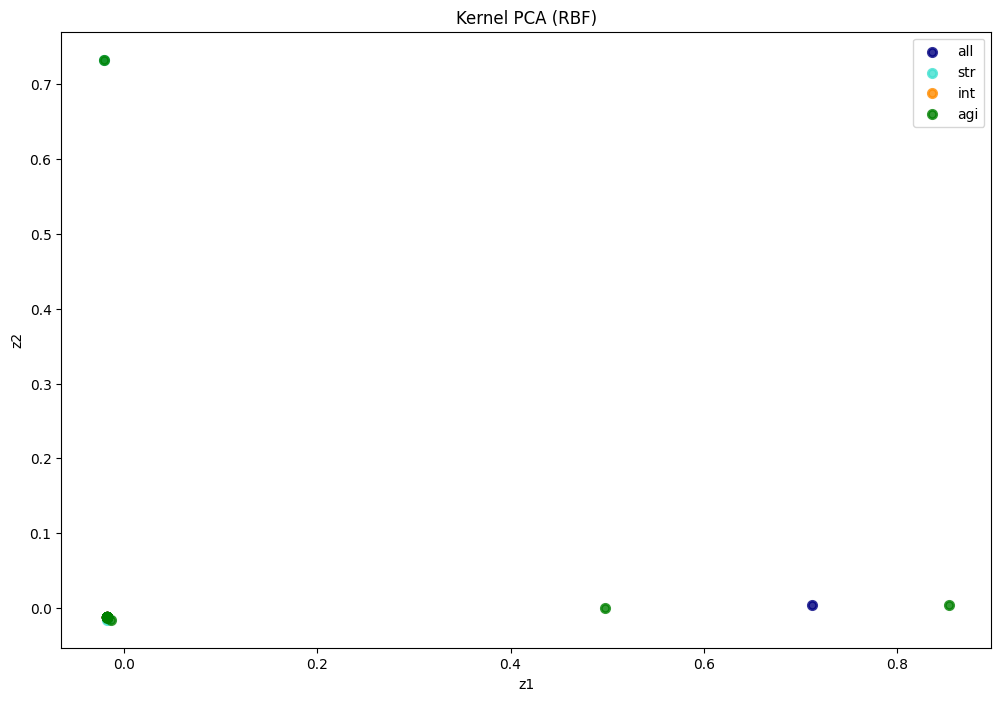

In [12]:
plt.figure(figsize=(12, 8))
colors = ["navy", "turquoise", "darkorange", "green"]
lw = 2

for color, i, target_name in zip(colors, [0, 1, 2, 3], vals):
    plt.scatter(
        X_new[y == i, 0], X_new[y == i, 1], color=color, alpha=0.8, lw=lw, label=vals[i]
    )

plt.legend(loc="best", shadow=False, scatterpoints=1)
plt.title("Kernel PCA (RBF)")
plt.xlabel("z1")
plt.ylabel("z2")
plt.show()

In [13]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2)
X_new = tsne.fit_transform(X)

In [14]:
# Вывод результатов
print('Initial Shape of X: ', X.shape)
print('New Shape of X: ', X_new.shape)
print('Kullback-Leibler divergence after optimization: ', tsne.kl_divergence_)
print('No. of iterations: ', tsne.n_iter_)
#print('Embedding vectors: ', tsne.embedding_)

Initial Shape of X:  (124, 5)
New Shape of X:  (124, 2)
Kullback-Leibler divergence after optimization:  0.18085849285125732
No. of iterations:  849


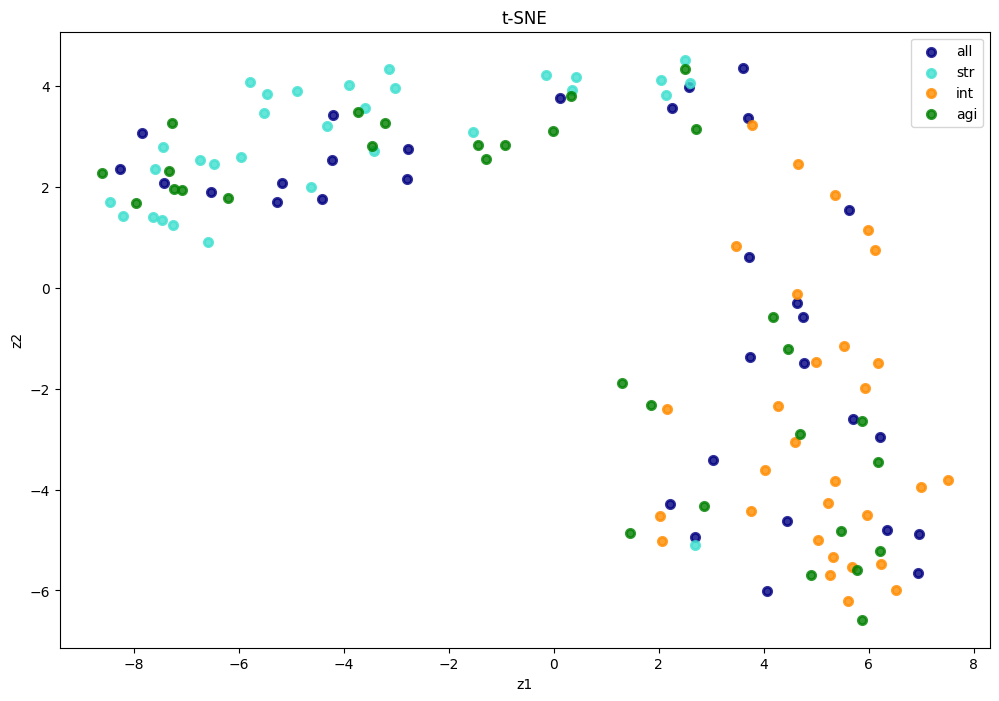

In [15]:
plt.figure(figsize=(12, 8))
colors = ["navy", "turquoise", "darkorange", "green"]
lw = 2

for color, i, target_name in zip(colors, [0, 1, 2, 3], vals):
    plt.scatter(
        X_new[y == i, 0], X_new[y == i, 1], color=color, alpha=0.8, lw=lw, label=vals[i]
    )

plt.legend(loc="best", shadow=False, scatterpoints=1)
plt.title("t-SNE")
plt.xlabel("z1")
plt.ylabel("z2")
plt.show()

In [16]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.metrics import v_measure_score

In [17]:
dbscan_cluster1 = DBSCAN(eps=0.5, min_samples=5)
X_new = dbscan_cluster1.fit(X)

In [18]:
# Number of Clusters
labels = dbscan_cluster1.labels_
N_clus = len(set(labels)) - (1 if -1 in labels else 0)
print('Estimated no. of clusters: %d' % N_clus)

# Identify Noise
n_noise = list(dbscan_cluster1.labels_).count(-1)
print('Estimated no. of noise points: %d' % n_noise)

# Calculating v_measure
print('v_measure =', v_measure_score(y, labels))

Estimated no. of clusters: 0
Estimated no. of noise points: 124
v_measure = 0.0


/tmp/ipykernel_3787/2363839577.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="best", shadow=False, scatterpoints=2)


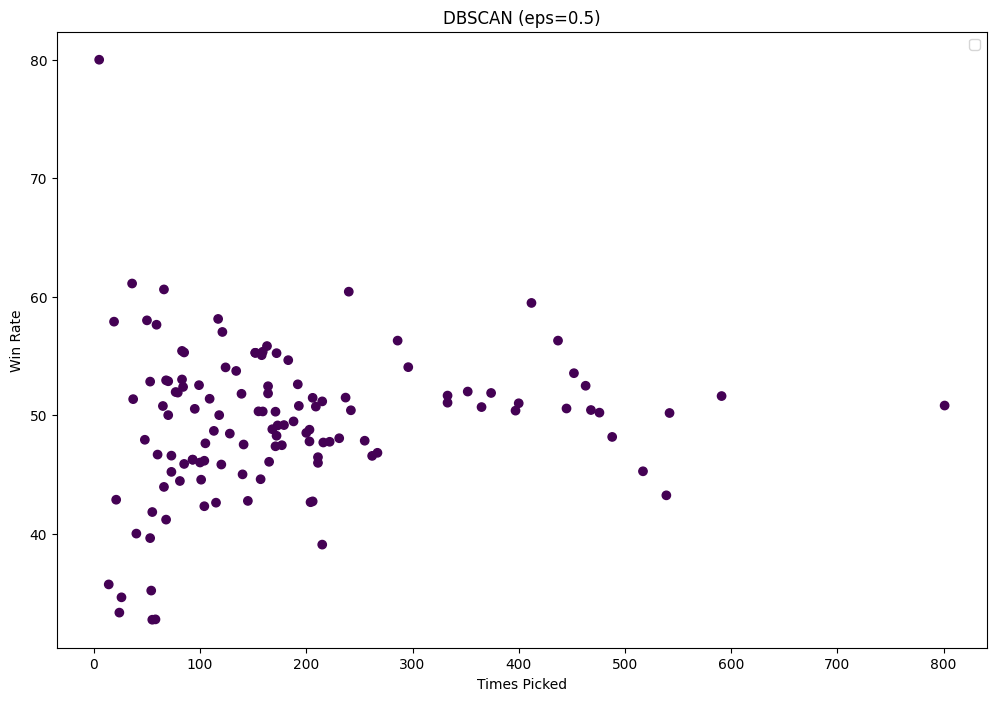

In [19]:
plt.figure(figsize=(12, 8))
colors = ["navy", "turquoise", "darkorange", "green"]
lw = 2

plt.scatter(
    X['Times Picked'], X['Win Rate'], c=dbscan_cluster1.labels_
)

plt.legend(loc="best", shadow=False, scatterpoints=2)
plt.xlabel("Times Picked")
plt.ylabel("Win Rate")
plt.title("DBSCAN (eps=0.5)")
plt.show()

In [20]:
from sklearn.neighbors import NearestNeighbors

min_samples = 10

knn = NearestNeighbors(n_neighbors=min_samples, metric='l2')
knn.fit(X)

dists, inds = knn.kneighbors(X)
dists_ar = dists[:, 1:min_samples].mean(axis=1)
dists_ar.sort()

In [21]:
import sklearn
# возможные метрики расстояния
sklearn.metrics.pairwise.distance_metrics()

{'cityblock': <function sklearn.metrics.pairwise.manhattan_distances(X, Y=None)>,
 'cosine': <function sklearn.metrics.pairwise.cosine_distances(X, Y=None)>,
 'euclidean': <function sklearn.metrics.pairwise.euclidean_distances(X, Y=None, *, Y_norm_squared=None, squared=False, X_norm_squared=None)>,
 'haversine': <function sklearn.metrics.pairwise.haversine_distances(X, Y=None)>,
 'l2': <function sklearn.metrics.pairwise.euclidean_distances(X, Y=None, *, Y_norm_squared=None, squared=False, X_norm_squared=None)>,
 'l1': <function sklearn.metrics.pairwise.manhattan_distances(X, Y=None)>,
 'manhattan': <function sklearn.metrics.pairwise.manhattan_distances(X, Y=None)>,
 'precomputed': None,
 'nan_euclidean': <function sklearn.metrics.pairwise.nan_euclidean_distances(X, Y=None, *, squared=False, missing_values=nan, copy=True)>}

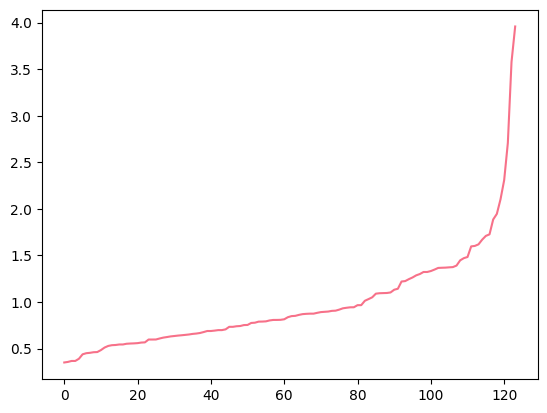

In [28]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

min_samples = 5  # увеличим для большей устойчивости
knn = NearestNeighbors(n_neighbors=min_samples)
knn.fit(X_scaled)
distances, _ = knn.kneighbors(X_scaled)
distances = np.sort(distances[:, -1])

plt.plot(distances)
plt.show()

In [23]:
dbscan = DBSCAN(eps=0.35, min_samples=min_samples)
print(dbscan)

DBSCAN(eps=0.35)


In [24]:
pred = dbscan.fit_predict(X)

In [25]:
# Number of Clusters
labels = dbscan.labels_
N_clus = len(set(labels)) - (1 if -1 in labels else 0)
print('Estimated no. of clusters: %d' % N_clus)

# Identify Noise
n_noise = list(dbscan.labels_).count(-1)
print('Estimated no. of noise points: %d' % n_noise)

# Calculating v_measure
print('v_measure =', v_measure_score(y, labels))

Estimated no. of clusters: 0
Estimated no. of noise points: 124
v_measure = 0.0


In [26]:
# у аномалий - класс -1, ищем все номера строк с таким классом, потом отбираем эти строки из начального набора данных

anom_index = [i for i in range(len(pred)) if pred[i] == -1]
values = X.loc[X.index[anom_index]]

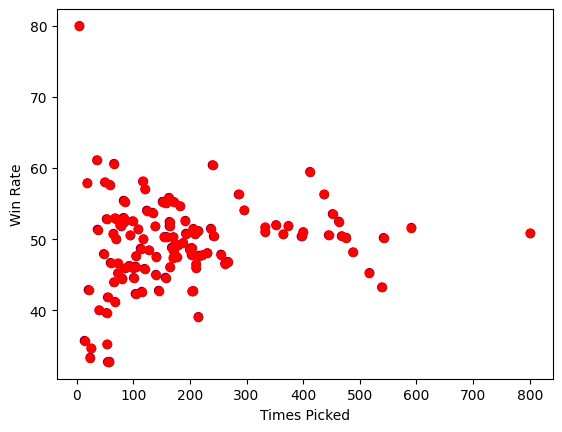

In [29]:
plt.scatter(X['Times Picked'], X['Win Rate'], c=dbscan_cluster1.labels_)
plt.scatter(values['Times Picked'], values['Win Rate'], color='r')
plt.xlabel("Times Picked")
plt.ylabel("Win Rate")
plt.show()